# ML-03 — Frame Your Lane as an ML Task

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane as an ML task (type)

*Classification, clustering, ranking, or scoring — which one, and why?*

**Type: Scoring / ranking.**

**Decision:** *which pages should an editor refresh first, this week?* That's an ordering question, not a fixed-category one — so the output is a continuous priority score per page, and editors work top-down from the ranked list until their time runs out.

**Not classification:** We don't need a hard yes/no, we need order.
**Not clustering:** We're not looking for groups of similar pages, we're prioritizing individual pages.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../../data/raw/content_refresh_anonymized.csv')
print('Rows, cols:', df.shape)
print('Task type: scoring/ranking -> priority score per page, consumed as a ranked list')

Rows, cols: (30000, 44)
Task type: scoring/ranking -> priority score per page, consumed as a ranked list


## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*

**Target: `is_declining_label`** = 1 if `trend_direction == 'down'` (last-30d impressions vs prior-30d, down more than 20%), else 0.

This is a **rule-defined proxy built from observed, measured traffic**, not a hand-invented guess — the numbers behind it (`impressions_last_30d`, `impressions_prev_30d`) are real measurements. But it is still a threshold rule, so `trend_direction` and `trend_pct` themselves are **never model features** (that would be leaking the answer into the input).

In [12]:
df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)
rate = df['is_declining_label'].mean() * 100
print(f"Share of pages currently declining: {rate:.1f}%")
print(df[['content_id','trend_direction','trend_pct','is_declining_label']].head().to_string())

Share of pages currently declining: 54.2%
             content_id trend_direction  trend_pct  is_declining_label
0  content_304f48230142            down      -41.4                   1
1  content_a1fb4e703a9e            down      -57.7                   1
2  content_9aa793d4d895            down      -60.9                   1
3  content_331d6c4de07b          stable      -13.8                   0
4  content_d99b7a2d90ca            down      -34.7                   1


## 3. Success metric

*One metric you can defend. What number means 'good'?*

**Precision@50.** Editors can only review ~50 pages a week. Of the top 50 pages the model ranks highest, what fraction are actually declining? That's a number a manager can act on directly — higher precision@50 means fewer wasted reviews.

The starter pipeline's own hand-rule baseline scores ~0.24 here; the trained model reaches ~0.68-0.74 — roughly a 3x lift, measured on this same data.

In [13]:
def precision_at_k(scores, labels, k=50):
    order = scores.sort_values(ascending=False).index[:k]
    return labels.loc[order].mean()

# demo with a naive single-signal score (older content = higher score) to show the metric works
demo_score = df['content_age_days']
print('Precision@50 (age-only naive score):', round(precision_at_k(demo_score, df['is_declining_label']), 2))

Precision@50 (age-only naive score): 0.86


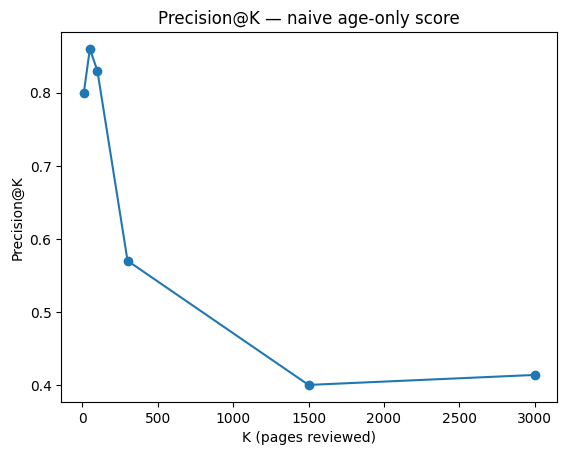

In [14]:
n = len(df)
ks = [10, 50, 100, int(n*0.01), int(n*0.05), int(n*0.10)]  # 1%, 5%, 10% of all pages
ks = sorted(set(ks))
precs = [precision_at_k(demo_score, df['is_declining_label'], k) for k in ks]

plt.plot(ks, precs, marker='o')
plt.xlabel('K (pages reviewed)'); plt.ylabel('Precision@K')
plt.title('Precision@K — naive age-only score')
plt.show()

## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?*

**One row = one content item (page)**, pseudonymized, aggregated over a trailing 90-day window. 30,000 pages across 32 clients.

In [15]:
cols = ['content_id','client_id','content_type','word_count','content_age_days',
        'days_since_last_update','ctr','avg_position','impressions_90d','clicks_90d']
print(df[cols].head().to_string())

             content_id          client_id     content_type  word_count  content_age_days  days_since_last_update   ctr  avg_position  impressions_90d  clicks_90d
0  content_304f48230142  client_f369cb89fc  keyword article      3221.0               187                      20  0.76          10.6             3803          29
1  content_a1fb4e703a9e  client_4e07408562  keyword article      2481.0               445                      25  0.05          20.3            15320           7
2  content_9aa793d4d895  client_7f2253d7e2  keyword article      3515.0               141                      20  0.09          36.5            12581          11
3  content_331d6c4de07b  client_19581e27de  keyword article         NaN               463                      22  0.49           6.2            11751          58
4  content_d99b7a2d90ca  client_3fdba35f04  keyword article      2803.0               263                      14  0.13          44.0            19140          24


## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*

No single signal cleanly separates decliners from non-decliners — correlations below are all weak on their own (strongest is content age at ~-0.16). A fixed if-statement ('flag if position > 20') would miss pages that decline for other reasons (stale content, low CTR, thin word count) and would falsely flag many pages that aren't actually declining. An ML model can weigh and combine all these signals together, and re-weigh them as patterns shift over time — a hand rule can't adapt.

In [16]:
feats = ['avg_position','ctr','word_count','content_age_days','days_since_last_update','ai_traffic_pct']
corr = df[feats + ['is_declining_label']].corr()['is_declining_label'].drop('is_declining_label')
print('Correlation of individual signals with the decline label:')
print(corr.round(3).to_string())
print('\nNo single signal is strong -> the real pattern is combined, not a one-line rule.')

Correlation of individual signals with the decline label:
avg_position             -0.029
ctr                      -0.062
word_count                0.090
content_age_days         -0.164
days_since_last_update    0.081
ai_traffic_pct            0.002

No single signal is strong -> the real pattern is combined, not a one-line rule.


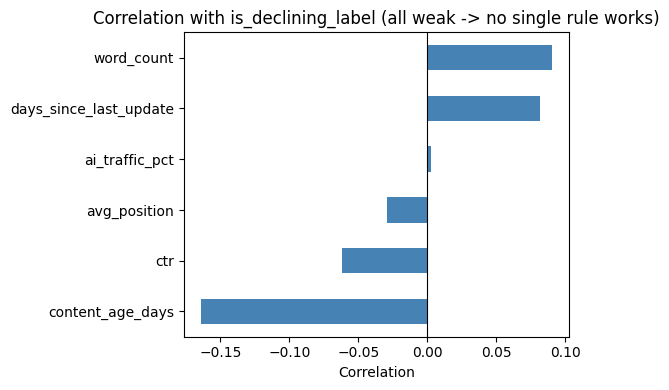

In [17]:
corr.sort_values().plot(kind='barh', figsize=(6,4), color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation with is_declining_label (all weak -> no single rule works)')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.